In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [3]:
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

In [4]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             

In [5]:
print("\nClass Distribution:")
print(df['target'].value_counts())


Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


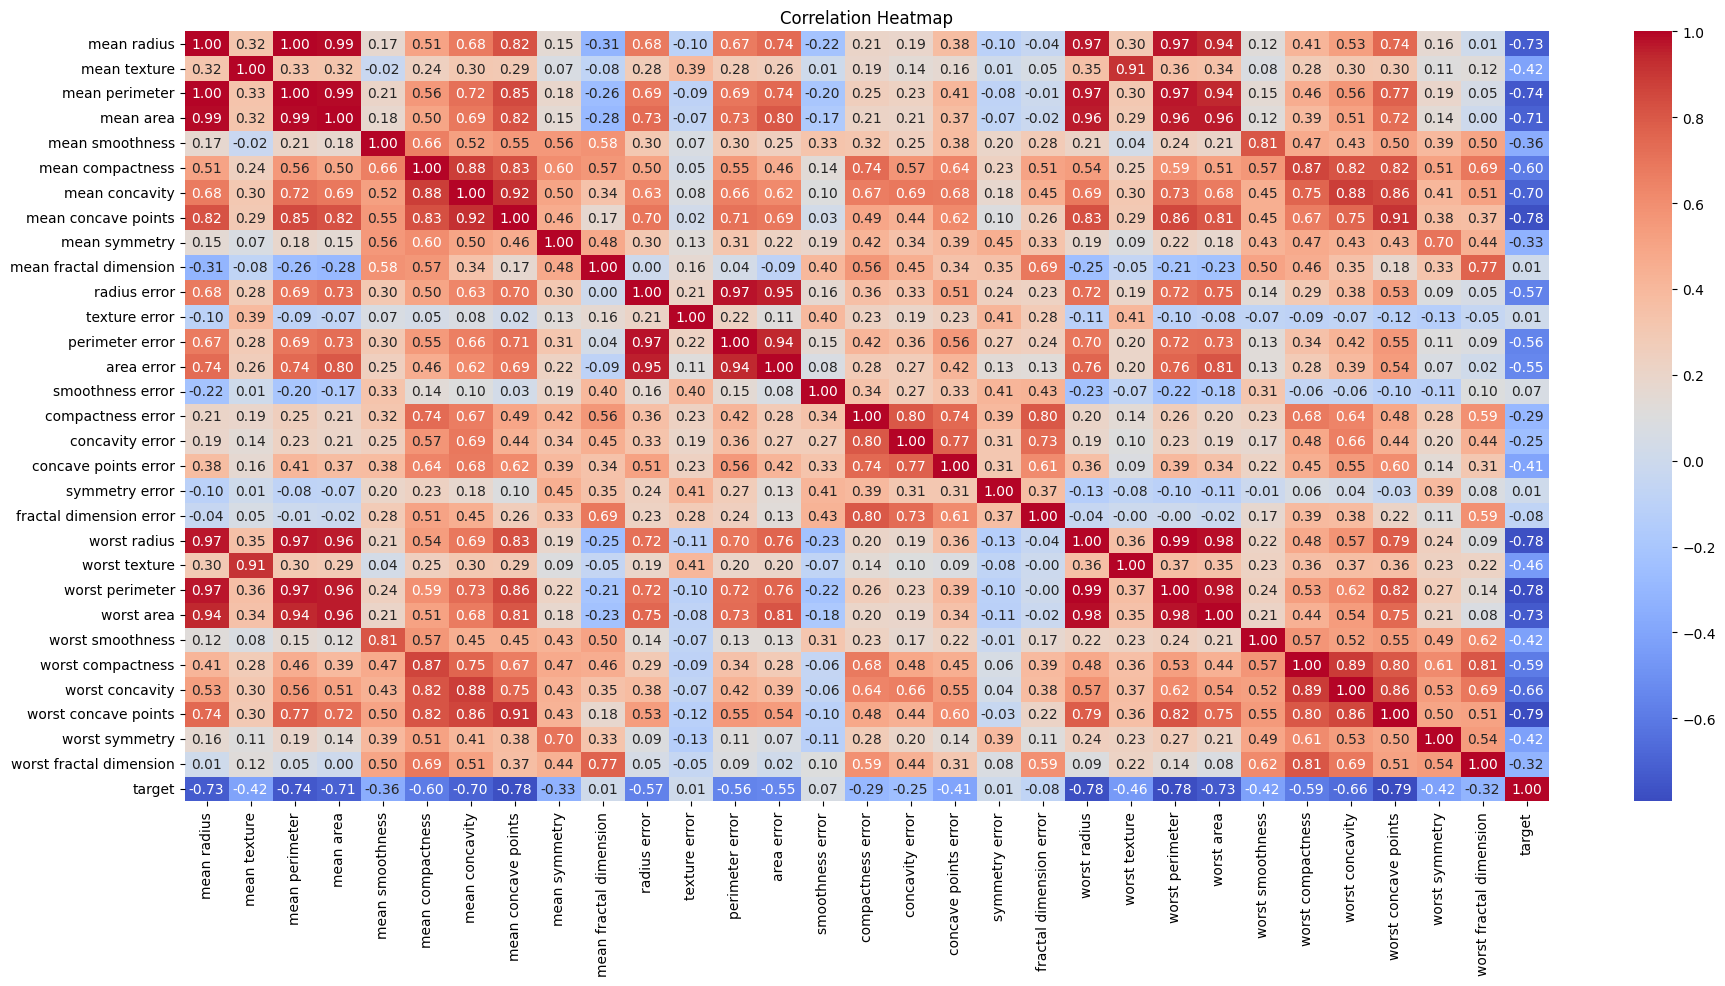

In [8]:
plt.figure(figsize=(22,10))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

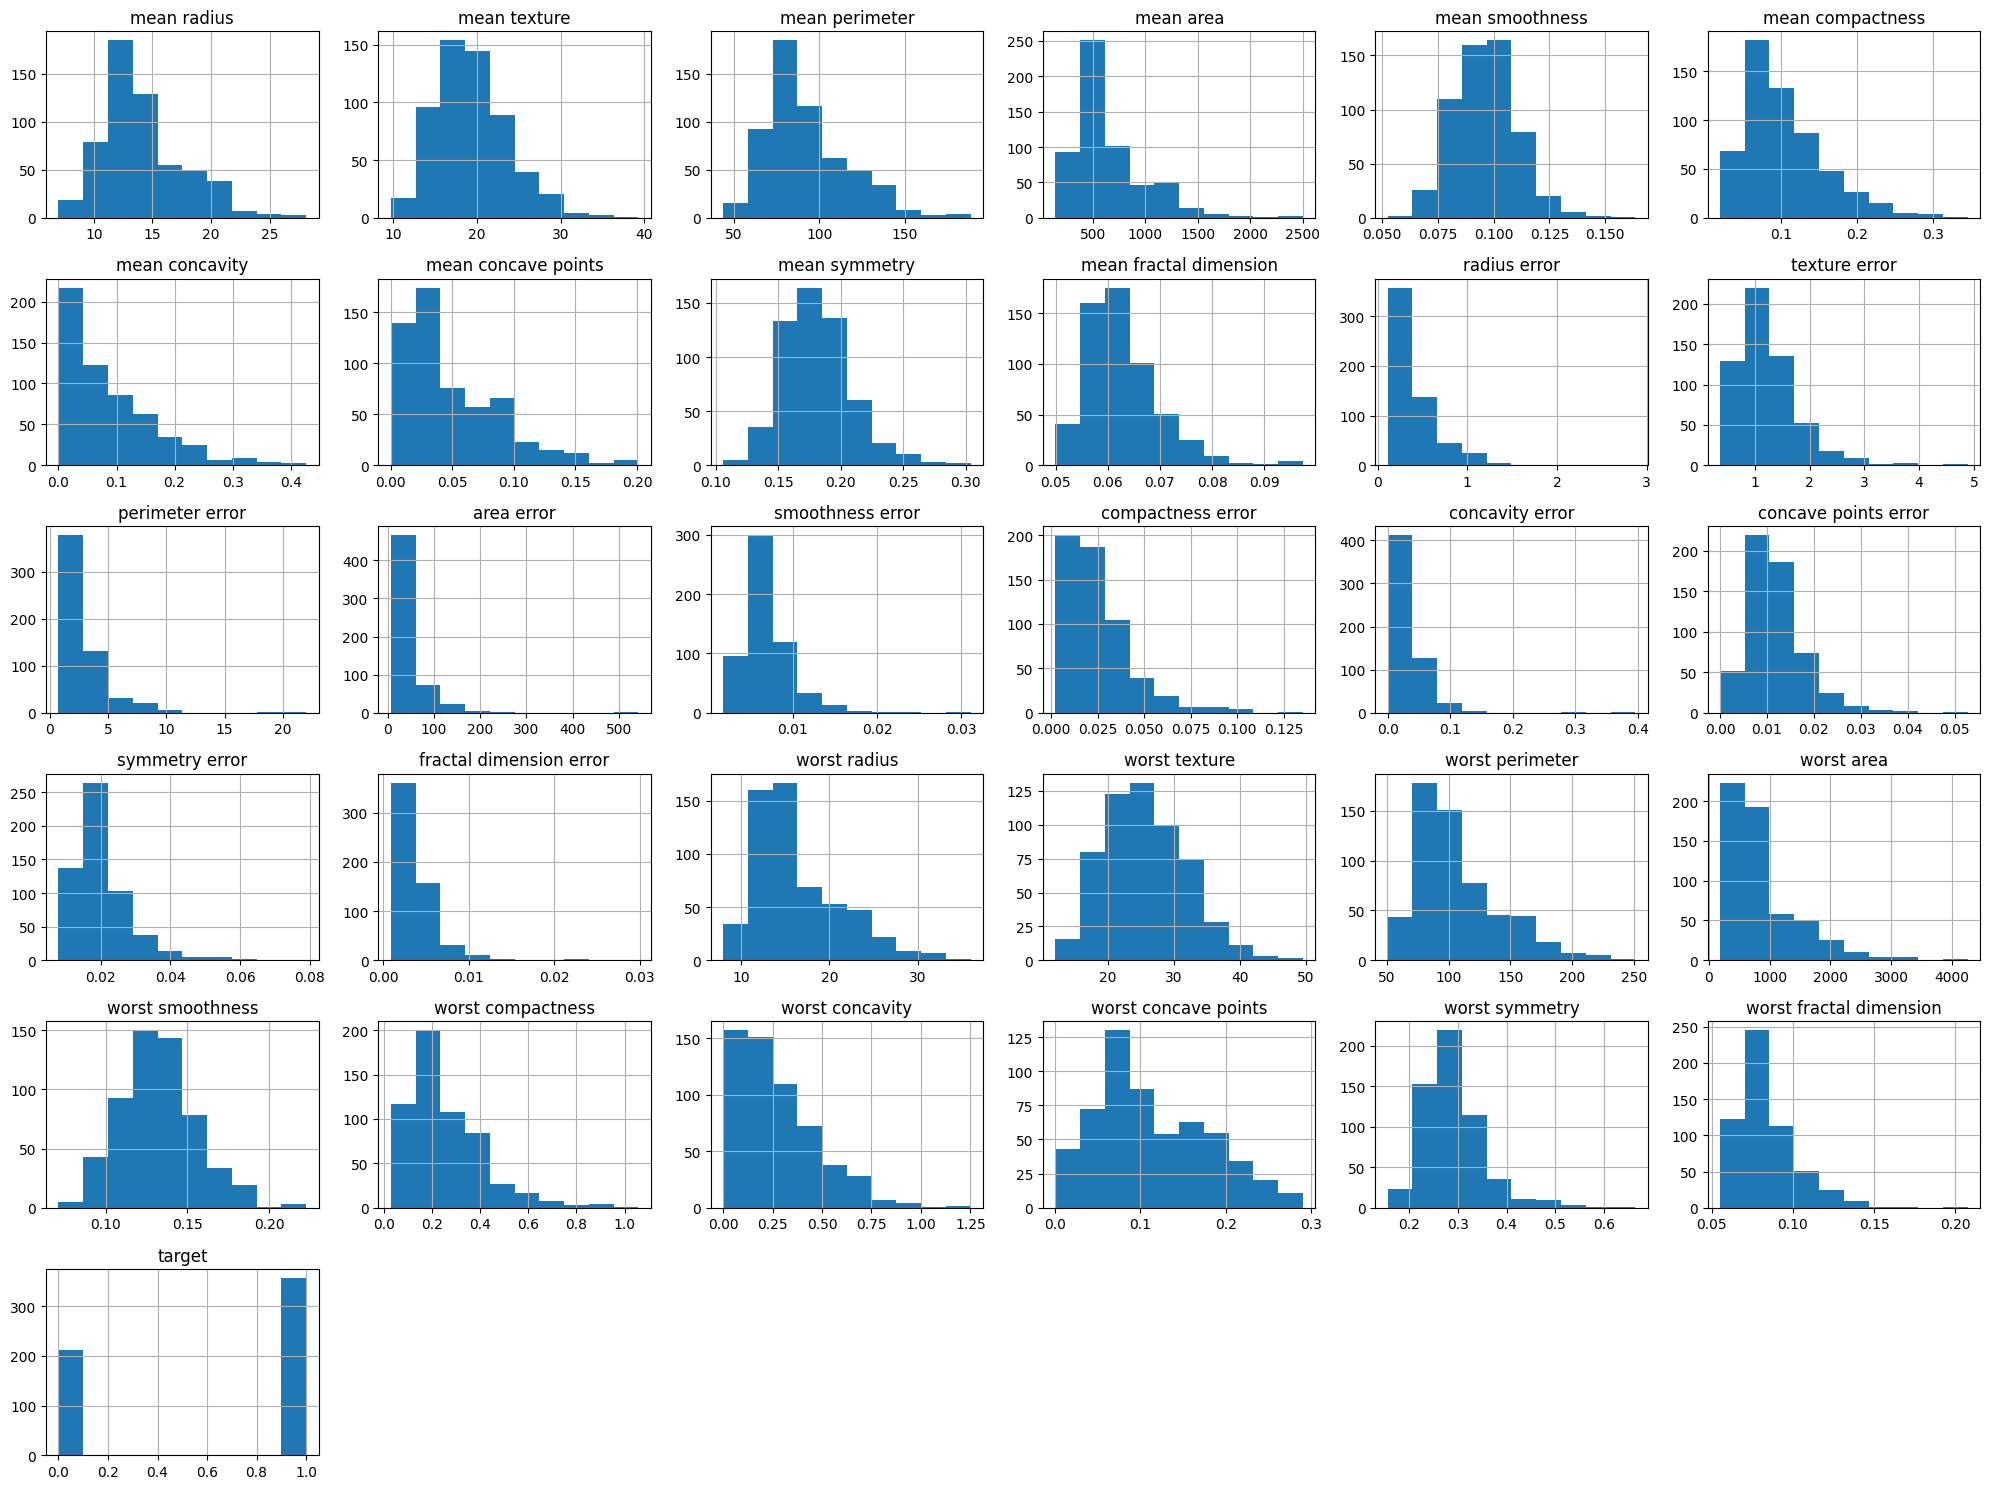

In [9]:
df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

In [10]:
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) |
                (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df_clean = remove_outliers_iqr(df)
print("After Outlier Removal:", df_clean.shape)

X = df_clean.drop("target", axis=1).values
y = df_clean["target"].values

After Outlier Removal: (398, 31)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
class CustomModel:
    def __init__(self, lr=0.01, epochs=1000, mode="perceptron"):
        self.lr = lr
        self.epochs = epochs
        self.mode = mode

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            linear = np.dot(X, self.weights) + self.bias

            if self.mode == "perceptron":
                y_pred = np.where(linear > 0, 1, 0)
                error = y - y_pred
                self.weights += self.lr * np.dot(X.T, error)
                self.bias += self.lr * np.sum(error)

            elif self.mode == "logistic":
                y_pred = self.sigmoid(linear)
                error = y - y_pred
                self.weights += self.lr * np.dot(X.T, error)
                self.bias += self.lr * np.sum(error)

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias

        if self.mode == "perceptron":
            return np.where(linear > 0, 1, 0)
        else:
            return np.where(self.sigmoid(linear) > 0.5, 1, 0)

    def predict_proba(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear)

In [13]:
perceptron = CustomModel(mode="perceptron")
perceptron.fit(X_train, y_train)
y_pred_p = perceptron.predict(X_test)

In [14]:
logistic = CustomModel(mode="logistic")
logistic.fit(X_train, y_train)
y_pred_l = logistic.predict(X_test)
y_proba = logistic.predict_proba(X_test)

C:\Users\dk331\AppData\Local\Temp\ipykernel_5020\3557940050.py:8: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


In [15]:
def evaluate(y_test, y_pred, y_proba=None):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    if y_proba is not None:
        print("ROC AUC:", roc_auc_score(y_test, y_proba))


In [16]:
print("\nPerceptron Results:")
evaluate(y_test, y_pred_p)



Perceptron Results:
Accuracy: 0.875
Precision: 0.9090909090909091
Recall: 0.9090909090909091
F1 Score: 0.9090909090909091
Confusion Matrix:
 [[20  5]
 [ 5 50]]


In [17]:
print("\nLogistic Regression Results:")
evaluate(y_test, y_pred_l, y_proba)


Logistic Regression Results:
Accuracy: 0.875
Precision: 0.9090909090909091
Recall: 0.9090909090909091
F1 Score: 0.9090909090909091
Confusion Matrix:
 [[20  5]
 [ 5 50]]
ROC AUC: 0.8545454545454546


In [18]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(max_iter=5000)
cv_scores = cross_val_score(sk_model, X, y, cv=5)

print("\nCross Validation Accuracy:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross Validation Accuracy: [0.925      0.9375     0.9875     0.93670886 0.94936709]
Mean CV Accuracy: 0.9472151898734177
